In [13]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE, mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE, mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import seaborn as sns


In [14]:
# Load the data
df= pd.read_csv("insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
df.shape

(1338, 7)

In [16]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [17]:
# No of categories in region
df['region'].nunique()

4

In [18]:
# unique categories in region
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [19]:
# Converts categorical columns to numerical in sex, region, smoker
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

# Onehot encoding for region
df = pd.get_dummies(df, columns=['region'], drop_first=True)
df.head()




,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [20]:
# Remove NaN values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Reset the index
df = df.reset_index(drop=True)


RFE

RandomForestRegressor

In [21]:
# X/y -split
X = df.drop("charges", axis=1)
y = df['charges']

# Use RandomForestRegressor
model = RandomForestRegressor()

# create RFE
rfe = RFE(estimator=model, n_features_to_select=5)

# fit the RFE model
rfe.fit(X, y)

# Ranking of the features
rankings = rfe.ranking_
support = rfe.support_

# Show results
RandomForest_df = pd.DataFrame({
    "Feature": X.columns,
    "Ranking": rankings,
    "Selected": support
}).sort_values(by="Ranking")

RandomForest_df

,Feature,Ranking,Selected
0,age,1,True
2,bmi,1,True
3,children,1,True
4,smoker,1,True
5,region_northwest,1,True
6,region_southeast,2,False
1,sex,3,False
7,region_southwest,4,False


DecisionTreeRegressor

In [22]:
# X/y -split for the model
X = df.drop("charges", axis=1)
y = df['charges']

# Use DecisionTreeRegressor
model = DecisionTreeRegressor()

# create RFE
rfe = RFE(estimator=model, n_features_to_select=7)

# fit the RFE model
rfe.fit(X, y)

# Ranking of the features and their support
rankings = rfe.ranking_
support = rfe.support_

# Show results of RFE
DecisionTree_df = pd.DataFrame({
    "Feature": X.columns,
    "Ranking": rankings,
    "Selected": support
}).sort_values(by="Ranking")

DecisionTree_df

,Feature,Ranking,Selected
0,age,1,True
1,sex,1,True
2,bmi,1,True
3,children,1,True
4,smoker,1,True
5,region_northwest,1,True
7,region_southwest,1,True
6,region_southeast,2,False


CORRELATIONS

<Axes: >

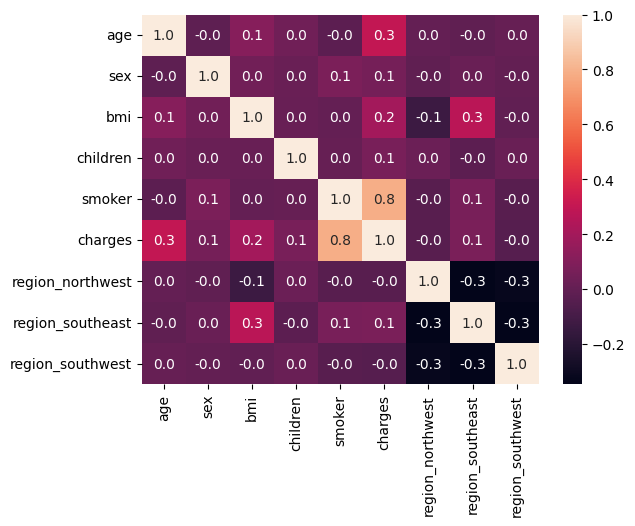

In [23]:
sns.heatmap(df.corr(), annot=True, fmt=".1f")

MUTUAL INFORMATION

In [24]:
# fit the mutual information algorithm
mtl = mutual_info_regression(X, y)

# convert results into DataFrame
mtl_results = pd.Series(mtl, index=X.columns).sort_values(ascending=False)

mtl_results

age                 1.500029
smoker              0.369276
sex                 0.176281
children            0.160903
bmi                 0.072676
region_northwest    0.056791
region_southeast    0.035002
region_southwest    0.002465
dtype: float64